## Exercise 1

### 1a. Load data

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

Data skulle indeholde følgende: 569 clinical samples and 30 tumor-related features.

In [2]:
np.shape(df)

(569, 30)

Vi vælger 'mean area' som vores kontinuere biomedicinske variabel.

In [3]:
data = df['mean area']

### 1b. Plot histogram and QQ-plot.

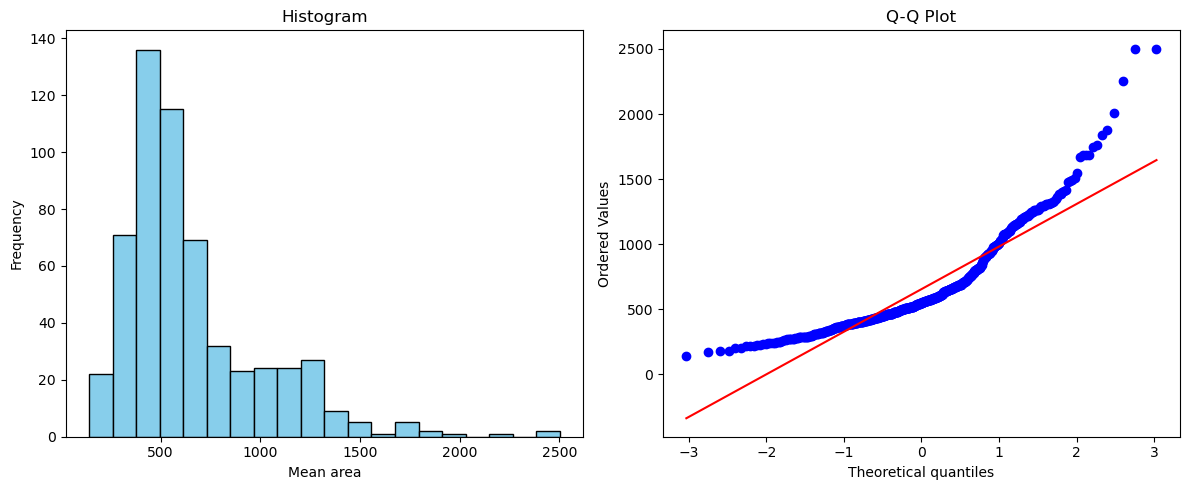

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Create distribution + QQ plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(data, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Mean area')
axes[0].set_ylabel('Frequency')

# QQ Plot with scipy (normal reference)
stats.probplot(data, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()

Fra både histogram og Q-Q plot ser det ikke ud som at data er normalfordelte.

### 1c. Test for normality using Shapiro-Wilk.

In [31]:
shapiro_result = stats.shapiro(data).pvalue
print(f'Shapiro-Wilk:{shapiro_result}')

Shapiro-Wilk:nan


C:\Users\Niels\AppData\Local\Temp\ipykernel_3364\3543080085.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  shapiro_result = stats.shapiro(data).pvalue


Med en p-værdi under 0.05 i testen afvises nul-hypotesen om at data er normalfordelte.

### 1d. Apply a log transformation

Vi log transformerer data for at se om dette kan gøre data normalfordelte.

In [15]:
log_data = np.log(data)

### 1e. Plot histogram & Q–Q plot (after transform)

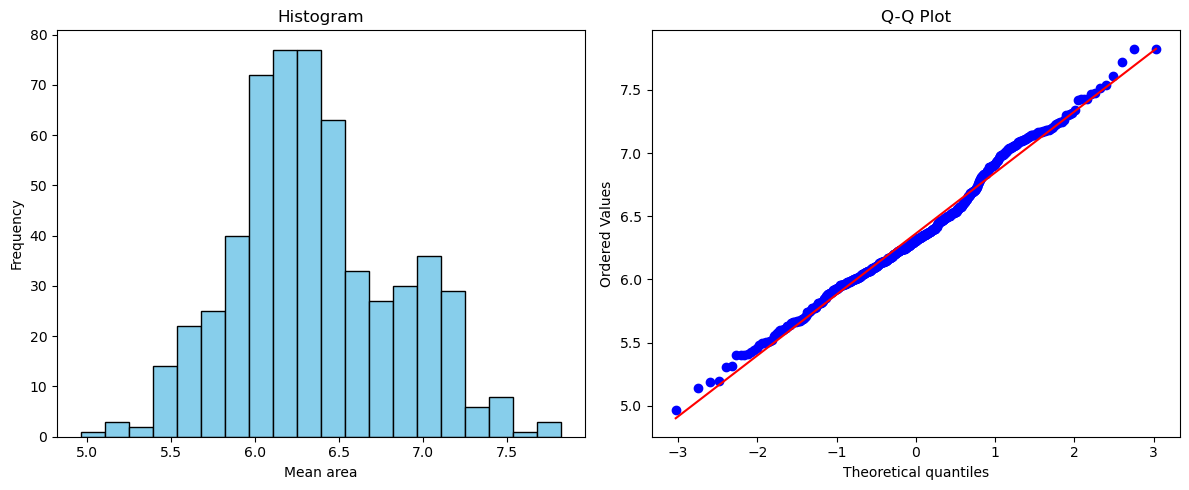

In [16]:
# Create distribution + QQ plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(log_data, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Mean area')
axes[0].set_ylabel('Frequency')

# QQ Plot with scipy (normal reference)
stats.probplot(log_data, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()

Fra histogram og Q-Q plot ser de log transformerede data nu normalfordelte ud.

### 1f. Re-test normality after log transformation

In [18]:
shapiro_result = stats.shapiro(log_data).pvalue
print('Shapiro-Wilk:', shapiro_result)

Shapiro-Wilk: 0.0001091582588219218


Shapiro-Wilk test kan dog stadig ikke bekræfte nul-hypotesen om at data er normalfordelte.

## Exercise 2. 
One-Way ANOVA on Serum Cholesterol Across Chest Pain Types

### 2a. Load the real biomedical dataset
"heart_disease" fra seaborn eksisterer ikke. Istedet har vi fundet et forhåbentligt lignende dataset fra sklearn.datasets.

Vi kigger specifikt på kolesterol (chol) og brystsmerte (cp) værdier.

In [34]:
from sklearn.datasets import fetch_openml
import pandas as pd

heart = fetch_openml(name="heart-disease", version=1, as_frame=True)
df = heart.frame.copy()

df["chol"] = pd.to_numeric(df["chol"])
df["cp"] = pd.to_numeric(df["cp"])

describe() giver et overblik over fordelingen af værdier for f.eks. cp og chol i datasættet.

In [35]:
df[['cp', 'chol']].describe()

,cp,chol
count,303.000000,303.000000
mean,0.966997,246.264026
std,1.032052,51.830751
min,0.000000,126.000000
25%,0.000000,211.000000
50%,1.000000,240.000000
75%,2.000000,274.500000
max,3.000000,564.000000


Med value_counts() kan vi se hvor mange gange forskellige cp værdier er givet til patienterne.

In [33]:
df['cp'].value_counts()

cp
0.0    143
2.0     87
1.0     50
3.0     23
Name: count, dtype: int64

### 2b. Split cholesterol values by chest-pain group 1-4.
Her kan vi bruge Pythons comprehension til at lave en dictionary over grupperne.

In [45]:
chol_cp_groups = {i: df.loc[df["cp"] == i,"chol"] for i in [1, 2, 3, 4]}

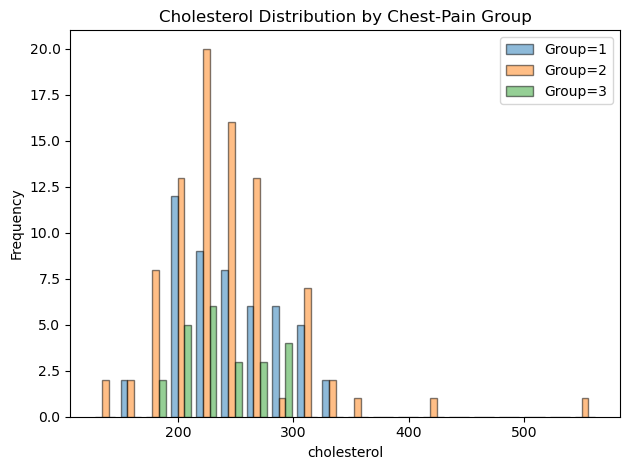

In [44]:
import matplotlib.pyplot as plt

plot_groups = {
    i: df.loc[df["cp"] == i, "chol"].dropna().to_numpy()
    for i in [1, 2, 3, 4]
}
plot_groups = {k: v for k, v in plot_groups.items() if len(v) > 0}

# Prepare data
data = list(plot_groups.values())
labels = [f"Group={k}" for k in plot_groups.keys()]

# Single combined histogram
plt.hist(data, bins=20, alpha=0.5, edgecolor="black", label=labels)

plt.title("Cholesterol Distribution by Chest-Pain Group")
plt.xlabel("cholesterol")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### 2c. Check ANOVA assumptions (normality and equal variances).

Test af normalitet med Shapiro-Wilk.

In [46]:
from scipy.stats import ttest_ind
from scipy.stats import shapiro

for group, data in chol_cp_groups.items():
    # Test normality with Shapiro-Wilk
    if len(data) >= 3:
        stat, p = shapiro(data)
        if p > 0.05:
            print(f"Group {group} follows a normal distribution. p={p:.2}")
        else:
            print(f"Group {group} DOES NOT follow a normal distribution. p={p:.2}")
    else: print(f"Sample size to small for Group {group}")

Group 1 follows a normal distribution. p=0.34
Group 2 DOES NOT follow a normal distribution. p=2.3e-07
Group 3 follows a normal distribution. p=0.41
Sample size to small for Group 4


Test af ens varians med levene.

In [25]:
from scipy.stats import levene
for group_A in range(1,5):
    for group_B in range(group_A+1,5):
        data_A = chol_cp_groups[group_A]
        data_B = chol_cp_groups[group_B]
        if len(data_A) & len(data_B):
            stat, p = levene(data_A, data_B)
            if p > 0.05:
                print(f"Groups {group_A} and {group_B} have equal variances. p={p:.2}")
            else:
                print(f"Groups {group_A} and {group_B} DOES NOT have equal variances. p={p:.2}")

Groups 1 and 2 have equal variances. p=0.43
Groups 1 and 3 have equal variances. p=0.16
Groups 2 and 3 have equal variances. p=0.15


### 2d. Run One-Way ANOVA

In [26]:
from scipy.stats import f_oneway
f_stat, p_value = f_oneway(chol_cp_groups[1], chol_cp_groups[2], chol_cp_groups[3])
print("F =", f_stat)
print("p =", p_value)

F = 0.1733209417714393
p = 0.8410283712705904


Da p > 0.05 kan vi ikke forkaste nul-hypotesen om at middelværdierne er ens for de 3 grupper.

### 2e. If significant, run Tukey HSD (Honestly Significant Difference)

Da vi ikke så en forskel i ANOVA testen. Giver Tukey ikke mening.

### 2f. Visualize the results using boxplots.

Igen giver denne ikke mening, da der ikke er forskel på grupperne.